# QM640 Data Analytics Capstone

## AI-Driven Predictive Resource Optimization for On-Premises Virtualized Enterprise Data Centers Using Machine Learning

### Project Overview

This notebook is the primary research workspace for the QM640 Data Analytics Capstone project. It provides a structured and reproducible workflow for preparing the Google Colab environment, acquiring the selected dataset, examining infrastructure telemetry, engineering predictive features, evaluating forecasting models, and generating materials for the final capstone report.

The study examines whether machine learning and time-series forecasting can support proactive resource management in on-premises virtualized enterprise data centers. The analysis focuses on short-term forecasting of central processing unit (CPU) and memory utilization, identification of influential infrastructure metrics, comparison with traditional threshold-based monitoring, and estimation of potential operational benefits.

---

## Research Objectives

- Forecast CPU and memory utilization over 5-minute, 15-minute, and 30-minute horizons.
- Compare multiple machine-learning and time-series forecasting approaches.
- Identify the infrastructure metrics that contribute most strongly to prediction accuracy.
- Evaluate whether predictive alerts can identify bottlenecks earlier than static threshold rules.
- Estimate the effect of predictive optimization on resource utilization, operational efficiency, and return on investment.

---
## Dataset

This project uses the publicly available **Bitbrains GWA-T-12 Virtual Machine Workload Traces**. The dataset contains anonymized, timestamped performance measurements collected from enterprise virtual machines, including:

- CPU capacity and utilization
- Provisioned and active memory
- Disk read and write throughput
- Network receive and transmit throughput
- Virtual-machine identifiers and timestamps

**Official dataset source:**  
https://atlarge-research.com/gwa-t-12/

The primary analysis uses the `fastStorage` trace because it provides detailed virtual-machine workload measurements suitable for short-horizon infrastructure forecasting.

---

## Evidence Generated for the Synopsis and Final Report

### Dataset Validation

- Dataset preview using `df.head()`
- Dataset dimensions using `df.shape`
- Column names and data types using `df.info()`
- Descriptive statistics using `df.describe()`
- Missing-values summary
- Duplicate-record checks
- Timestamp-range and sampling-interval checks

### Exploratory Analysis

- CPU utilization distribution
- Memory utilization distribution
- Disk I/O and network-throughput summaries
- Correlation matrix
- Sample CPU and memory time-series plots
- Resource-utilization trends and variability

### Modeling and Evaluation

- Forecast targets for 5-, 15-, and 30-minute horizons
- Baseline and machine-learning model results
- Feature-importance analysis
- Threshold-based versus predictive-alert comparison
- Operational-efficiency and ROI estimates

---

## Reproducibility

This project is designed to support a reproducible research workflow. All data preparation, preprocessing, exploratory analysis, feature engineering, and model evaluation steps are documented within this notebook and executed in a sequential manner.

The notebook automatically prepares the project environment, loads the selected dataset, performs the required analyses, and stores generated outputs, figures, and reports in Google Drive. This enables the complete workflow to be repeated using the same dataset and methodology.

The project repository includes the source code, documentation, dependency list, and project structure required to reproduce the analysis and verify the reported results.

---

## Expected Project Structure

```text
AI-Predictive-Resource-Optimization/
├── data/
│   ├── raw/
│   └── processed/
├── notebooks/
├── src/
├── images/
├── reports/
├── docs/
├── README.md
├── requirements.txt
└── .gitignore
```

---

## Author

**Yashwanth Sairam Dudi**  
QM640: Data Analytics Capstone  
Walsh College


## Step 1 — Mount Google Drive

Approve access when Google asks. The project will be stored under:

`MyDrive/AIML-Masters/Project/Capstone/AI-Predictive-Resource-Optimization`


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2 — Create the Colab Project Workspace

This cell creates the required repository folders directly in Google Drive.


In [2]:
from pathlib import Path
import os, sys, json, shutil, zipfile, subprocess, textwrap

DRIVE_ROOT = Path('/content/drive/MyDrive/AIML-Masters/Project/Capstone/')
PROJECT_ROOT = DRIVE_ROOT / 'AI-Predictive-Resource-Optimization'

folders = [
    'data/downloads',
    'data/raw/bitbrains_faststorage',
    'data/processed',
    'notebooks',
    'src',
    'images',
    'reports',
    'docs',
]
for folder in folders:
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

os.chdir(PROJECT_ROOT)
print('Project root:', PROJECT_ROOT)
print('Current directory:', Path.cwd())


Project root: /content/drive/MyDrive/AIML-Masters/Project/Capstone/AI-Predictive-Resource-Optimization
Current directory: /content/drive/MyDrive/AIML-Masters/Project/Capstone/AI-Predictive-Resource-Optimization


## Step 3 — Install Required Packages


In [3]:
!pip -q install pandas numpy matplotlib scikit-learn xgboost statsmodels shap jupyterlab pytest


## Step 4 — Download the Official Bitbrains Dataset

The official dataset page is:

https://atlarge-research.com/gwa-t-12/

The notebook first attempts the official direct `fastStorage` ZIP URL. If the provider changes the direct link, update `FASTSTORAGE_URL` using the official dataset page.


In [4]:
from pathlib import Path
import urllib.request
import zipfile
import hashlib
import shutil
import os

OFFICIAL_PAGE = 'https://atlarge-research.com/gwa-t-12/'
FASTSTORAGE_URL = 'https://atlarge-research.com/gwa-traces/gwa_t_12_fastStorage.zip'

DOWNLOAD_DIR = PROJECT_ROOT / 'data/downloads'
ARCHIVE_PATH = DOWNLOAD_DIR / 'gwa_t_12_fastStorage.zip'
RAW_DIR = PROJECT_ROOT / 'data/raw/bitbrains_faststorage'
STAGING_DIR = PROJECT_ROOT / 'data/_faststorage_extract'

existing_files = [p for p in RAW_DIR.iterdir() if p.is_file() and not p.name.startswith('.')]

if existing_files:
    print(f'Dataset already available: {len(existing_files)} files. Download skipped.')
else:
    print('Downloading official fastStorage trace...')
    print('Official page:', OFFICIAL_PAGE)
    print('Direct URL:', FASTSTORAGE_URL)

    request = urllib.request.Request(
        FASTSTORAGE_URL,
        headers={'User-Agent': 'Mozilla/5.0 QM640-Capstone-Colab'}
    )
    try:
        with urllib.request.urlopen(request, timeout=120) as response, ARCHIVE_PATH.open('wb') as output:
            total = int(response.headers.get('Content-Length', 0))
            downloaded = 0
            while True:
                block = response.read(1024 * 1024)
                if not block:
                    break
                output.write(block)
                downloaded += len(block)
                if total:
                    print(f'\r{downloaded/total*100:6.2f}%  '
                          f'{downloaded/1024/1024:,.1f}/{total/1024/1024:,.1f} MB',
                          end='')
                else:
                    print(f'\rDownloaded {downloaded/1024/1024:,.1f} MB', end='')
        print('\nDownload complete:', ARCHIVE_PATH)
    except Exception as exc:
        raise RuntimeError(
            'Automatic download failed. Open the official dataset page in a browser, '
            'download the fastStorage ZIP, upload it to '
            f'{DOWNLOAD_DIR}, and rerun this cell. Original error: {exc}'
        )

    if not zipfile.is_zipfile(ARCHIVE_PATH):
        raise RuntimeError('The downloaded file is not a valid ZIP archive.')

    digest = hashlib.sha256()
    with ARCHIVE_PATH.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    print('SHA-256:', digest.hexdigest())

    if STAGING_DIR.exists():
        shutil.rmtree(STAGING_DIR)
    STAGING_DIR.mkdir(parents=True)

    with zipfile.ZipFile(ARCHIVE_PATH) as archive:
        archive.extractall(STAGING_DIR)

    candidates = [
        p for p in STAGING_DIR.rglob('*')
        if p.is_file() and not p.name.startswith('.')
    ]

    copied = 0
    for source in candidates:
        destination = RAW_DIR / source.name
        if destination.exists():
            continue
        shutil.copy2(source, destination)
        copied += 1

    shutil.rmtree(STAGING_DIR)
    print(f'Copied {copied} files to {RAW_DIR}')


Dataset already available: 1250 files. Download skipped.


## Step 5 — Verify and Load the Bitbrains Dataset

This step confirms that the extracted VM trace files are available, assigns the official dataset schema, converts timestamps, derives memory utilization, and validates the first trace before analysis.


In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

COLUMNS = [
    'timestamp_ms',
    'cpu_cores',
    'cpu_capacity_mhz',
    'cpu_usage_mhz',
    'cpu_usage_pct',
    'memory_provisioned_kb',
    'memory_usage_kb',
    'disk_read_kbps',
    'disk_write_kbps',
    'network_received_kbps',
    'network_transmitted_kbps',
]

def list_trace_files(directory):
    directory = Path(directory)
    return sorted(
        p for p in directory.iterdir()
        if p.is_file() and not p.name.startswith('.')
    )

def load_vm_trace(path):
    path = Path(path)
    frame = pd.read_csv(
        path,
        sep=r';\s*',
        engine='python',
        header=None,
        comment='#'
    )
    if frame.shape[1] != len(COLUMNS):
        raise ValueError(
            f'Expected {len(COLUMNS)} columns but found {frame.shape[1]} in {path.name}'
        )
    frame.columns = COLUMNS

    # Explicitly convert numeric columns to appropriate types
    numeric_cols = [
        'timestamp_ms', 'cpu_cores', 'cpu_capacity_mhz', 'cpu_usage_mhz',
        'cpu_usage_pct', 'memory_provisioned_kb', 'memory_usage_kb',
        'disk_read_kbps', 'disk_write_kbps', 'network_received_kbps',
        'network_transmitted_kbps'
    ]
    for col in numeric_cols:
        frame[col] = pd.to_numeric(frame[col], errors='coerce')

    # Drop rows where timestamp_ms could not be converted to a number
    frame.dropna(subset=['timestamp_ms'], inplace=True)

    frame['timestamp'] = pd.to_datetime(
        frame['timestamp_ms'], unit='ms', utc=True, errors='coerce'
    )
    frame['vm_id'] = path.stem
    denominator = frame['memory_provisioned_kb'].replace(0, np.nan)
    frame['memory_usage_pct'] = frame['memory_usage_kb'] / denominator * 100
    return frame

trace_files = list_trace_files(RAW_DIR)
if not trace_files:
    raise FileNotFoundError(f'No trace files found in {RAW_DIR}')

print('Trace files found:', len(trace_files))
print('First file:', trace_files[0].name)

df = load_vm_trace(trace_files[0])
assert not df.empty
assert df['timestamp'].notna().all()
print('Initial validation passed.')


Trace files found: 1250
First file: 1.csv
Initial validation passed.


## Step 6 — Required Dataset Evidence

These cells generate the exact evidence requested by the instructor.


In [6]:
display(df.head())
print('df.shape =', df.shape)


,timestamp_ms,cpu_cores,cpu_capacity_mhz,cpu_usage_mhz,cpu_usage_pct,memory_provisioned_kb,memory_usage_kb,disk_read_kbps,disk_write_kbps,network_received_kbps,network_transmitted_kbps,timestamp,vm_id,memory_usage_pct
1,1.376315e+09,4.0,11703.99824,10912.027692,93.233333,67108864.0,6.129274e+06,0.133333,15981.600000,0.000000,2.133333,1970-01-16 22:18:34.846000+00:00,1,9.133331
2,1.376315e+09,4.0,11703.99824,10890.570362,93.050000,67108864.0,6.755624e+06,1.333333,19137.333333,0.000000,2.600000,1970-01-16 22:18:35.146000+00:00,1,10.066664
3,1.376315e+09,4.0,11703.99824,10434.114431,89.150000,67108864.0,8.947846e+06,2.533333,19974.933333,535.666667,23.933333,1970-01-16 22:18:35.446000+00:00,1,13.333330
4,1.376316e+09,4.0,11703.99824,10539.450415,90.050000,67108864.0,1.879048e+07,5.466667,8791.800000,349.666667,5.466667,1970-01-16 22:18:35.746000+00:00,1,27.999996
5,1.376316e+09,4.0,11703.99824,10951.041020,93.566667,67108864.0,9.305761e+06,5.400000,15679.533333,0.000000,2.066667,1970-01-16 22:18:36.046000+00:00,1,13.866664


df.shape = (8634, 14)


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 8634 entries, 1 to 8634
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   timestamp_ms              8634 non-null   float64            
 1   cpu_cores                 8634 non-null   float64            
 2   cpu_capacity_mhz          8634 non-null   float64            
 3   cpu_usage_mhz             8634 non-null   float64            
 4   cpu_usage_pct             8634 non-null   float64            
 5   memory_provisioned_kb     8634 non-null   float64            
 6   memory_usage_kb           8634 non-null   float64            
 7   disk_read_kbps            8634 non-null   float64            
 8   disk_write_kbps           8634 non-null   float64            
 9   network_received_kbps     8634 non-null   float64            
 10  network_transmitted_kbps  8634 non-null   float64            
 11  timestamp             

In [8]:
display(df.describe(include='all'))


,timestamp_ms,cpu_cores,cpu_capacity_mhz,cpu_usage_mhz,cpu_usage_pct,memory_provisioned_kb,memory_usage_kb,disk_read_kbps,disk_write_kbps,network_received_kbps,network_transmitted_kbps,timestamp,vm_id,memory_usage_pct
count,8.634000e+03,8634.0,8.634000e+03,8634.000000,8634.000000,8634.0,8.634000e+03,8634.000000,8634.000000,8634.000000,8634.000000,8634,8634,8634.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8634,NaN
mean,1.377611e+09,4.0,1.170400e+04,470.808807,4.022632,67108864.0,3.968319e+05,9.068713,412.470582,12.548241,2.982650,1970-01-16 22:40:11.018226662+00:00,NaN,0.591326
min,1.376315e+09,4.0,1.170400e+04,58.519991,0.500000,67108864.0,0.000000e+00,0.000000,0.285714,0.000000,0.928571,1970-01-16 22:18:34.846000+00:00,NaN,0.000000
25%,1.376962e+09,4.0,1.170400e+04,66.322657,0.566667,67108864.0,0.000000e+00,0.000000,0.600000,0.000000,1.000000,1970-01-16 22:29:22.386000+00:00,NaN,0.000000
50%,1.377611e+09,4.0,1.170400e+04,72.174656,0.616667,67108864.0,0.000000e+00,0.000000,0.666667,0.000000,1.000000,1970-01-16 22:40:11.428000+00:00,NaN,0.000000
75%,1.378259e+09,4.0,1.170400e+04,78.026655,0.666667,67108864.0,0.000000e+00,0.000000,1.000000,0.000000,1.000000,1970-01-16 22:50:59.261000+00:00,NaN,0.000000
max,1.378907e+09,4.0,1.170400e+04,11454.312944,97.866667,67108864.0,3.632826e+07,8544.733333,56630.600000,3563.800000,1022.666667,1970-01-16 23:01:46.798000+00:00,NaN,54.133330


In [9]:
missing_values = df.isna().sum().to_frame('missing_values')
display(missing_values)


,missing_values
timestamp_ms,0
cpu_cores,0
cpu_capacity_mhz,0
cpu_usage_mhz,0
cpu_usage_pct,0
memory_provisioned_kb,0
memory_usage_kb,0
disk_read_kbps,0
disk_write_kbps,0
network_received_kbps,0


## Step 7 — Combine a Reproducible Sample Across Multiple VMs

To keep exploratory analysis responsive in Colab, this cell loads a configurable number of VMs. Increase `NUMBER_OF_VMS` later when required.


In [10]:
NUMBER_OF_VMS = min(50, len(trace_files))

frames = []

for file_path in trace_files[:NUMBER_OF_VMS]:
    frame = load_vm_trace(file_path)
    frames.append(frame)

eda_df = pd.concat(frames, ignore_index=True)

print("=" * 75)
print("Bitbrains GWA-T-12 FastStorage Dataset Preview")
print("=" * 75)
print(f"Virtual Machine Trace Files Loaded : {eda_df['vm_id'].nunique()}")
print(
    f"Combined Dataset Size              : "
    f"{eda_df.shape[0]:,} rows × {eda_df.shape[1]} columns"
)
print("=" * 75)

display(eda_df.head())


Bitbrains GWA-T-12 FastStorage Dataset Preview
Virtual Machine Trace Files Loaded : 50
Combined Dataset Size              : 468,341 rows × 14 columns


,timestamp_ms,cpu_cores,cpu_capacity_mhz,cpu_usage_mhz,cpu_usage_pct,memory_provisioned_kb,memory_usage_kb,disk_read_kbps,disk_write_kbps,network_received_kbps,network_transmitted_kbps,timestamp,vm_id,memory_usage_pct
0,1.376315e+09,4.0,11703.99824,10912.027692,93.233333,67108864.0,6.129274e+06,0.133333,15981.600000,0.000000,2.133333,1970-01-16 22:18:34.846000+00:00,1,9.133331
1,1.376315e+09,4.0,11703.99824,10890.570362,93.050000,67108864.0,6.755624e+06,1.333333,19137.333333,0.000000,2.600000,1970-01-16 22:18:35.146000+00:00,1,10.066664
2,1.376315e+09,4.0,11703.99824,10434.114431,89.150000,67108864.0,8.947846e+06,2.533333,19974.933333,535.666667,23.933333,1970-01-16 22:18:35.446000+00:00,1,13.333330
3,1.376316e+09,4.0,11703.99824,10539.450415,90.050000,67108864.0,1.879048e+07,5.466667,8791.800000,349.666667,5.466667,1970-01-16 22:18:35.746000+00:00,1,27.999996
4,1.376316e+09,4.0,11703.99824,10951.041020,93.566667,67108864.0,9.305761e+06,5.400000,15679.533333,0.000000,2.066667,1970-01-16 22:18:36.046000+00:00,1,13.866664


## Step 8 — Generate Required Figures


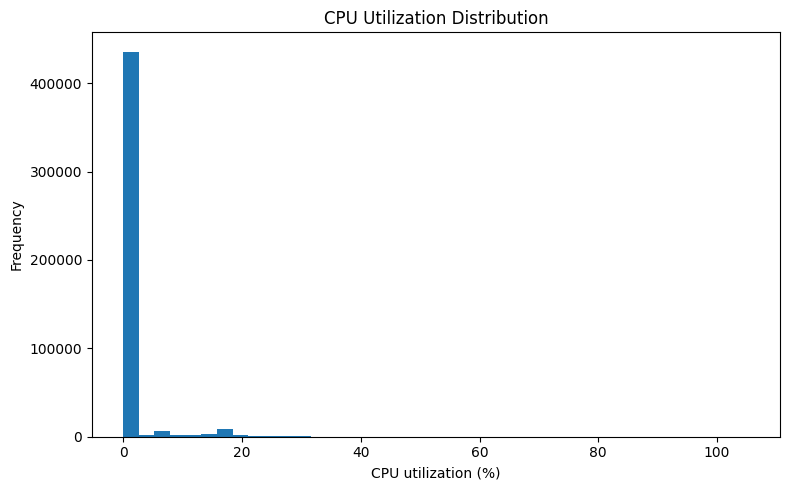

In [11]:
import matplotlib.pyplot as plt

IMAGE_DIR = PROJECT_ROOT / 'images'
IMAGE_DIR.mkdir(exist_ok=True)

figure, axis = plt.subplots(figsize=(8, 5))
axis.hist(eda_df['cpu_usage_pct'].dropna(), bins=40)
axis.set_title('CPU Utilization Distribution')
axis.set_xlabel('CPU utilization (%)')
axis.set_ylabel('Frequency')
figure.tight_layout()
figure.savefig(IMAGE_DIR / 'cpu_utilization_distribution.png', dpi=200)
plt.show()


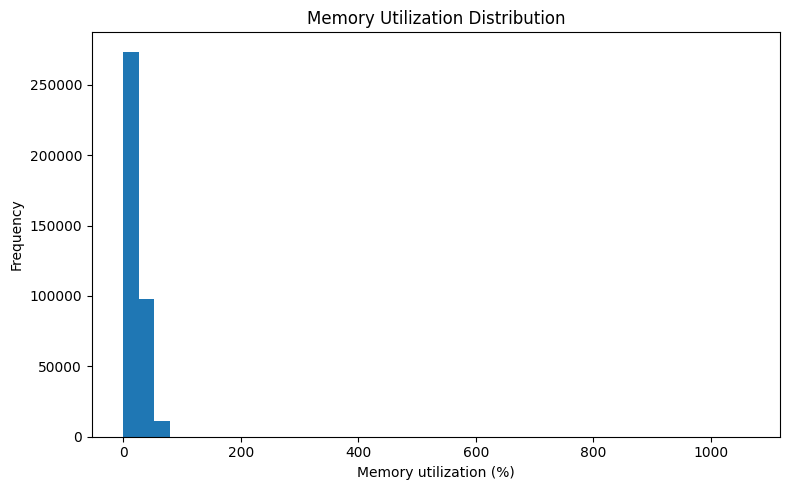

In [12]:
figure, axis = plt.subplots(figsize=(8, 5))
axis.hist(eda_df['memory_usage_pct'].dropna(), bins=40)
axis.set_title('Memory Utilization Distribution')
axis.set_xlabel('Memory utilization (%)')
axis.set_ylabel('Frequency')
figure.tight_layout()
figure.savefig(IMAGE_DIR / 'memory_utilization_distribution.png', dpi=200)
plt.show()


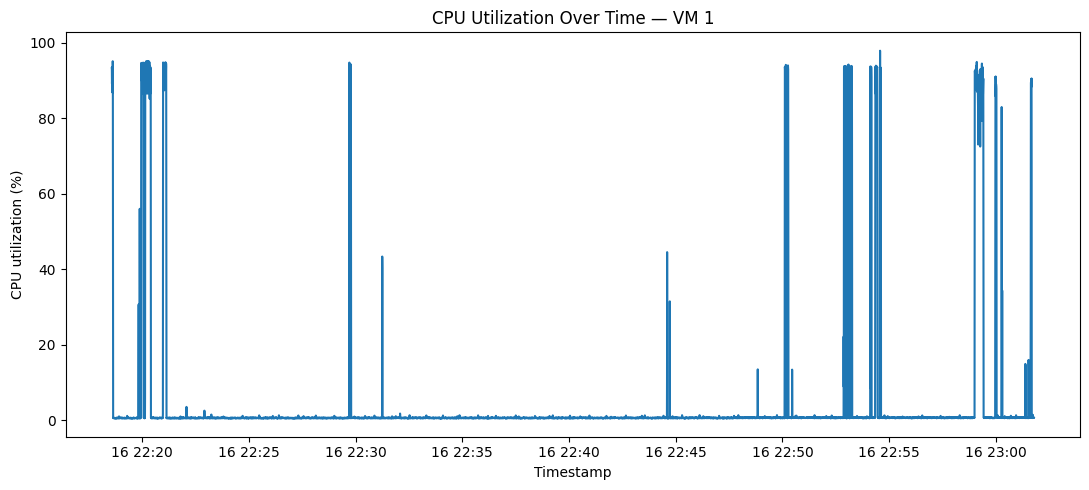

In [13]:
sample_vm = eda_df['vm_id'].iloc[0]
sample_series = eda_df[eda_df['vm_id'] == sample_vm].sort_values('timestamp')

figure, axis = plt.subplots(figsize=(11, 5))
axis.plot(sample_series['timestamp'], sample_series['cpu_usage_pct'])
axis.set_title(f'CPU Utilization Over Time — VM {sample_vm}')
axis.set_xlabel('Timestamp')
axis.set_ylabel('CPU utilization (%)')
figure.tight_layout()
figure.savefig(IMAGE_DIR / 'sample_cpu_time_series.png', dpi=200)
plt.show()


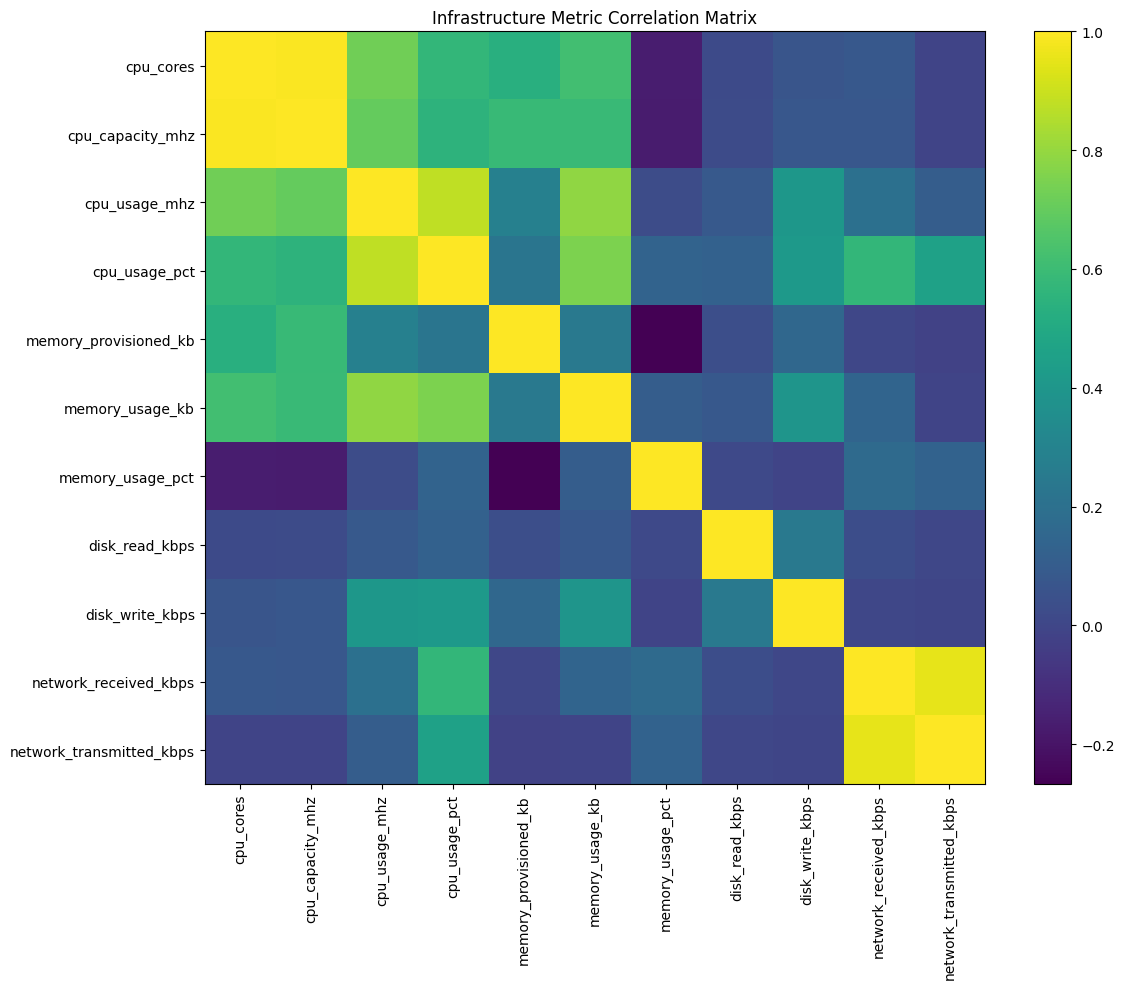

In [14]:
numeric_columns = [
    'cpu_cores', 'cpu_capacity_mhz', 'cpu_usage_mhz', 'cpu_usage_pct',
    'memory_provisioned_kb', 'memory_usage_kb', 'memory_usage_pct',
    'disk_read_kbps', 'disk_write_kbps',
    'network_received_kbps', 'network_transmitted_kbps'
]
correlation = eda_df[numeric_columns].corr()

figure, axis = plt.subplots(figsize=(12, 10))
image = axis.imshow(correlation, aspect='auto')
axis.set_xticks(range(len(numeric_columns)))
axis.set_xticklabels(numeric_columns, rotation=90)
axis.set_yticks(range(len(numeric_columns)))
axis.set_yticklabels(numeric_columns)
axis.set_title('Infrastructure Metric Correlation Matrix')
figure.colorbar(image, ax=axis)
figure.tight_layout()
figure.savefig(IMAGE_DIR / 'correlation_matrix.png', dpi=200)
plt.show()


## Step 9 — Save Dataset Evidence for the Synopsis

This step saves the dataset summary and descriptive evidence to the `reports` directory. The visualizations generated in Step 8 are retained in the `images` directory for inclusion in the synopsis and final report.


In [15]:
summary_path = PROJECT_ROOT / 'reports/dataset_summary.txt'
with summary_path.open('w', encoding='utf-8') as report:
    report.write(f'Official source: {OFFICIAL_PAGE}\n')
    report.write(f'Trace files found: {len(trace_files)}\n')
    report.write(f'VMs loaded for initial EDA: {eda_df.vm_id.nunique()}\n')
    report.write(f'Combined EDA shape: {eda_df.shape}\n')
    report.write(f'Timestamp minimum: {eda_df.timestamp.min()}\n')
    report.write(f'Timestamp maximum: {eda_df.timestamp.max()}\n')
    report.write('\nMissing values:\n')
    report.write(eda_df.isna().sum().to_string())
    report.write('\n\nDescriptive statistics:\n')
    report.write(eda_df.describe().to_string())

print('Saved:', summary_path)
print('Figures saved under:', IMAGE_DIR)


Saved: /content/drive/MyDrive/AIML-Masters/Project/Capstone/AI-Predictive-Resource-Optimization/reports/dataset_summary.txt
Figures saved under: /content/drive/MyDrive/AIML-Masters/Project/Capstone/AI-Predictive-Resource-Optimization/images
